# Time series of FHIST, OFFLHIST, and ILAMB

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import regionmask
import cartopy.crs as ccrs

import xclimate as xclim

%load_ext autoreload
%autoreload 2

In [2]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    # nmem='36GB',
    nmem='8GB',
    walltime='02:00:00'
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  8GB
walltime: 02:00:00


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39441 instead
  warnings.warn(


{'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 39441:128.117.211.161:39441 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:39441/status


In [3]:
# xclim.close_dask_cluster(client_cluster)

# Mask glaciated land

In [3]:
grid_ppe = xclim.load_fhist_ppe_grid()
grid_lens = xclim.load_cesm2le_grid()
grid_goga = xclim.load_goga2_grid()

NONGLC_PCT_THRESHOLD = 100  # maximum allowable percent of glaciated land for a NON-glaciated gridcell

nonglc_mask_ppe = grid_ppe.PCT_GLC <= NONGLC_PCT_THRESHOLD
nonglc_mask_lens = grid_lens.PCT_GLC <= NONGLC_PCT_THRESHOLD
nonglc_mask_goga = grid_goga.PCT_GLC <= NONGLC_PCT_THRESHOLD

# Load variables

In [4]:
tperiod = slice("1950-01", "2014-12")

## FHIST and OFFLHIST

In [7]:
# variables = [
#     "EFLX_LH_TOT_month_1",
#     "TLAI_month_1",
#     "TSA_month_1",
# ]

# fhist = {}
# ohist = {}
# for v in variables:
#     print(f"  {v}")
#     name = "_".join(v.split("_")[:-2])

#     fhist[v] = (
#         xclim.load_fhist(v, keep_var_only=True)[name]
#         .sel(time=tperiod)
#         .reindex_like(grid_ppe, method="nearest", tolerance=1e-3)
#         .where(nonglc_mask_ppe)
#         .chunk({'time': -1, 'lat': -1, 'lon': -1})
#         .persist()
#     )
#     fhist[v].attrs["masks"] = f"gridcell percent glaciated land <= {NONGLC_PCT_THRESHOLD}"

#     ohist[v] = (
#         xclim.load_offlhist(v, keep_var_only=True)[name]
#         .sel(time=tperiod)
#         .reindex_like(grid_ppe, method="nearest", tolerance=1e-3)
#         .where(nonglc_mask_ppe)
#         .chunk({'time': -1, 'lat': -1, 'lon': -1})
#         .persist()
#     )
#     ohist[v].attrs["masks"] = f"gridcell percent glaciated land <= {NONGLC_PCT_THRESHOLD}"

## LENS2 and GOGA

In [331]:
import importlib, xclimate.load
importlib.reload(xclimate.load)

variables_lens = [
    "EFLX_LH_TOT",
    "TLAI",
    "TSA",
]

lens = {}
goga = {}
for v in variables_lens:
    print(f"  {v}")
    vv = f"{v}_month_1"

    lens[vv] = (
        xclimate.load.load_cesm2le(v, "lnd", "month_1", "h0", keep_var_only=True)[v]
        .sel(time=tperiod)
        .reindex_like(grid_lens, method="nearest", tolerance=1e-3)
        .where(nonglc_mask_lens)
        .chunk({'time': -1, 'lat': -1, 'lon': -1})
        .persist()
    )
    lens[vv].attrs["masks"] = f"gridcell percent glaciated land <= {NONGLC_PCT_THRESHOLD}"

    goga[vv] = (
        xclimate.load.load_goga2(v, "lnd", "month_1", "h0", keep_var_only=True)[v]
        .sel(time=tperiod)
        .reindex_like(grid_goga, method="nearest", tolerance=1e-3)
        .where(nonglc_mask_goga)
        .chunk({'time': -1, 'lat': -1, 'lon': -1})
        .persist()
    )
    goga[vv].attrs["masks"] = f"gridcell percent glaciated land <= {NONGLC_PCT_THRESHOLD}"

  EFLX_LH_TOT
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 

10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 19.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  TLAI
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 19.25 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  TSA
1001
1021
1041
1061
1081
1101
1121
1141
1161
1181
1231
1 2 3 4 5 6 7 8 9 10 
1251
1 2 3 4 5 6 7 8 9 10 
1281
1 2 3 4 5 6 7 8 9 10 
1301
1 2 3 4 5 6 7 8 9 10 


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 19.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## ILAMB

In [8]:
from ILAMB import ilamblib

ilamb = {"hfls": {}, "lai": {}}
ilamb_area = {}
ilamb_landarea = {}

indir = Path("/glade/work/bbuchovecky/CPL_PPE_CO2/select_parameters/ILAMB_data/processed")
for f in indir.glob("annual_mean/*.nc"):
    key = f.stem.split("_")[2]
    var = f.stem.split("_")[0].lower()
    ilamb[var][key] = xr.open_dataset(f)[var].chunk({'year': -1}).persist()

# Load the land mask from the Natural Earth dataset
land = regionmask.defined_regions.natural_earth_v5_1_2.land_50

for key, ds in ilamb['hfls'].items():
    if 'lat_bounds' in ds.coords and 'lon_bounds' in ds.coords:
        print('  using bounds')
        method = 'bounds'
        lat_bounds = ds['lat_bounds'].values
        lon_bounds = ds['lon_bounds'].values
    else:
        print('  could not find bounds, using coordinates instead')
        method = 'coords'
        lat_bounds = None
        lon_bounds = None

    # Compute the cell areas using the ILAMB function
    ilamb_area[key] = ilamblib.CellAreas(
        lat=ds['lat'].values,
        lon=ds['lon'].values,
        lat_bnds=lat_bounds,
        lon_bnds=lon_bounds,
    )

    ilamb_area[key] = xr.DataArray(ilamb_area[key], dims=['lat', 'lon'], coords={'lat': ds['lat'], 'lon': ds['lon']})
    ilamb_area[key].attrs['units'] = 'm2'
    ilamb_area[key].attrs['long_name'] = 'grid cell area'
    ilamb_area[key].attrs['method'] = method

    # Create a land mask for the dataset using the Natural Earth land mask
    lnd_mask = xr.where(np.isnan(land.mask(lon_or_obj=ilamb_area[key].lon, lat=ilamb_area[key].lat)), 0, 1)
    ilamb_landarea[key] = ilamb_area[key] * lnd_mask
    ilamb_landarea[key].attrs['units'] = 'm2'
    ilamb_landarea[key].attrs['long_name'] = 'land grid cell area'
    ilamb_landarea[key].attrs['method'] = method

  could not find bounds, using coordinates instead
  could not find bounds, using coordinates instead
  could not find bounds, using coordinates instead
  could not find bounds, using coordinates instead
  could not find bounds, using coordinates instead
  could not find bounds, using coordinates instead
  could not find bounds, using coordinates instead


# Create region masks

## Amazon and Southwest US (with regionmask)

In [9]:
for state in ["CA", "NV", "UT", "AZ", "NM", "CO"]:
    print(regionmask.defined_regions.natural_earth_v5_0_0.us_states_50[state])

<regionmask._OneRegion: California (CA / 4)>
<regionmask._OneRegion: Nevada (NV / 33)>
<regionmask._OneRegion: Utah (UT / 44)>
<regionmask._OneRegion: Arizona (AZ / 3)>
<regionmask._OneRegion: New Mexico (NM / 32)>
<regionmask._OneRegion: Colorado (CO / 5)>


In [10]:
region_idx_srex_amazon = 7
region_idx_states_swus = [3, 4, 5, 32, 33, 44]  # ["CA", "NV", "UT", "AZ", "NM", "CO"]

# mask_srex_ppe = regionmask.defined_regions.srex.mask(grid_ppe.lon, grid_ppe.lat)
# mask_srex_lens = regionmask.defined_regions.srex.mask(grid_lens.lon, grid_lens.lat)
# mask_srex_goga = regionmask.defined_regions.srex.mask(grid_goga.lon, grid_goga.lat)

# mask_amazon_ppe = mask_srex_ppe == region_idx_srex_amazon
# mask_amazon_lens = mask_srex_lens == region_idx_srex_amazon
# mask_amazon_goga = mask_srex_goga == region_idx_srex_amazon

# mask_states_ppe = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50.mask(grid_ppe.lon, grid_ppe.lat)
# mask_states_lens = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50.mask(grid_lens.lon, grid_lens.lat)
# mask_states_goga = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50.mask(grid_goga.lon, grid_goga.lat)

# mask_swus_ppe = xr.zeros_like(mask_states_ppe, dtype=bool)
# mask_swus_lens = xr.zeros_like(mask_states_lens, dtype=bool)
# mask_swus_goga = xr.zeros_like(mask_states_goga, dtype=bool)

# for idx in region_idx_states_swus:
#     mask_swus_ppe = (mask_states_ppe == idx) | mask_swus_ppe
#     mask_swus_lens = (mask_states_lens == idx) | mask_swus_lens
#     mask_swus_goga = (mask_states_goga == idx) | mask_swus_goga

# ILAMB
mask_amazon_ilamb = {}
mask_swus_ilamb = {}

for model, la in ilamb_landarea.items():
    mask_srex_ilamb = regionmask.defined_regions.srex.mask(la.lon, la.lat)
    mask_amazon_ilamb[model] = mask_srex_ilamb == region_idx_srex_amazon

    mask_states_ilamb = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50.mask(la.lon, la.lat)
    mask_swus_ilamb[model] = xr.zeros_like(mask_states_ilamb, dtype=bool)
    for idx in region_idx_states_swus:
        mask_swus_ilamb[model] = (mask_states_ilamb == idx) | mask_swus_ilamb[model]

## Congo

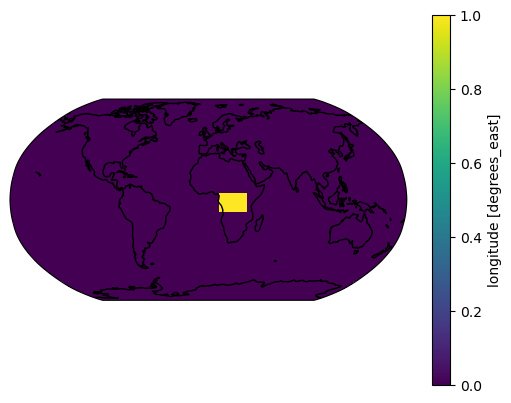

In [11]:
congo_lat_bounds = [-10, 5]
congo_lon_bounds = [10, 35]

# mask_congo_ppe = (
#     (grid_ppe.lat >= congo_lat_bounds[0])
#     & (grid_ppe.lat < congo_lat_bounds[1])
#     & (grid_ppe.lon >= congo_lon_bounds[0])
#     & (grid_ppe.lon < congo_lon_bounds[1])
# )

# mask_congo_lens = (
#     (grid_lens.lat >= congo_lat_bounds[0])
#     & (grid_lens.lat < congo_lat_bounds[1])
#     & (grid_lens.lon >= congo_lon_bounds[0])
#     & (grid_lens.lon < congo_lon_bounds[1])
# )

# mask_congo_goga = (
#     (grid_goga.lat >= congo_lat_bounds[0])
#     & (grid_goga.lat < congo_lat_bounds[1])
#     & (grid_goga.lon >= congo_lon_bounds[0])
#     & (grid_goga.lon < congo_lon_bounds[1])
# )

mask_congo_ilamb = {}
for model, la in ilamb_landarea.items():
    mask_congo_ilamb[model] = (
        (la.lat >= congo_lat_bounds[0])
        & (la.lat < congo_lat_bounds[1])
        & (la.lon >= congo_lon_bounds[0])
        & (la.lon < congo_lon_bounds[1])
    )

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
mask_congo_ilamb["CLASS"].plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()

## Northern Great Plains

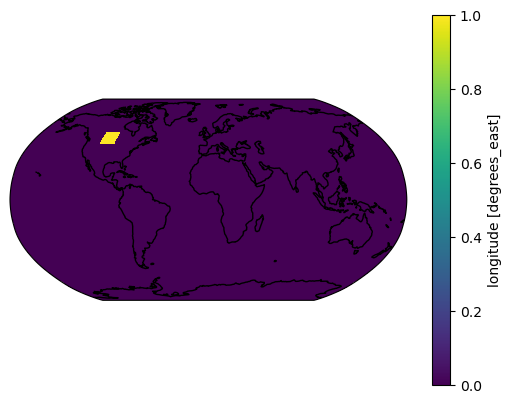

In [12]:
ngp_lat_bounds = [45, 55]
ngp_lon_bounds = [250, 265]

# mask_ngp_ppe = (
#     (grid_ppe.lat >= ngp_lat_bounds[0])
#     & (grid_ppe.lat < ngp_lat_bounds[1])
#     & (grid_ppe.lon >= ngp_lon_bounds[0])
#     & (grid_ppe.lon < ngp_lon_bounds[1])
# )

# mask_ngp_lens = (
#     (grid_lens.lat >= ngp_lat_bounds[0])
#     & (grid_lens.lat < ngp_lat_bounds[1])
#     & (grid_lens.lon >= ngp_lon_bounds[0])
#     & (grid_lens.lon < ngp_lon_bounds[1])
# )

# mask_ngp_goga = (
#     (grid_goga.lat >= ngp_lat_bounds[0])
#     & (grid_goga.lat < ngp_lat_bounds[1])
#     & (grid_goga.lon >= ngp_lon_bounds[0])
#     & (grid_goga.lon < ngp_lon_bounds[1])
# )

mask_ngp_ilamb = {}
for model, la in ilamb_landarea.items():
    mask_ngp_ilamb[model] = (
        (la.lat >= ngp_lat_bounds[0])
        & (la.lat < ngp_lat_bounds[1])
        & (la.lon >= ngp_lon_bounds[0] - 360)
        & (la.lon < ngp_lon_bounds[1] - 360)
    )

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
mask_ngp_ilamb["CLASS"].plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()

## Northern Russia

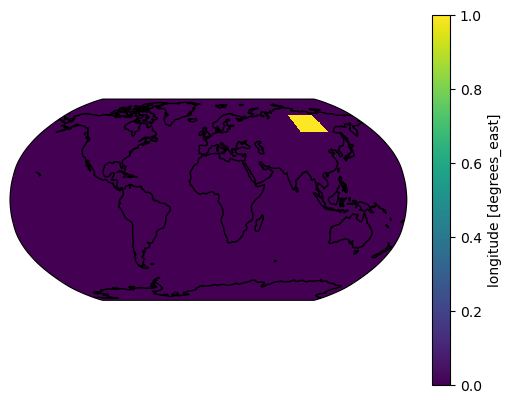

In [13]:
nru_lat_bounds = [55, 70]
nru_lon_bounds = [100, 130]

# mask_nru_ppe = (
#     (grid_ppe.lat >= nru_lat_bounds[0])
#     & (grid_ppe.lat < nru_lat_bounds[1])
#     & (grid_ppe.lon >= nru_lon_bounds[0])
#     & (grid_ppe.lon < nru_lon_bounds[1])
# )

# mask_nru_lens = (
#     (grid_lens.lat >= nru_lat_bounds[0])
#     & (grid_lens.lat < nru_lat_bounds[1])
#     & (grid_lens.lon >= nru_lon_bounds[0])
#     & (grid_lens.lon < nru_lon_bounds[1])
# )

# mask_nru_goga = (
#     (grid_goga.lat >= nru_lat_bounds[0])
#     & (grid_goga.lat < nru_lat_bounds[1])
#     & (grid_goga.lon >= nru_lon_bounds[0])
#     & (grid_goga.lon < nru_lon_bounds[1])
# )

mask_nru_ilamb = {}
for model, la in ilamb_landarea.items():
    mask_nru_ilamb[model] = (
        (la.lat >= nru_lat_bounds[0])
        & (la.lat < nru_lat_bounds[1])
        & (la.lon >= nru_lon_bounds[0])
        & (la.lon < nru_lon_bounds[1])
    )

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
mask_nru_ilamb["CLASS"].plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()

# Compute area mean

In [14]:
# fhist_et_ts = fhist["EFLX_LH_TOT_month_1"].weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# ohist_et_ts = ohist["EFLX_LH_TOT_month_1"].weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # lens_et_ts = lens["EFLX_LH_TOT_month_1"].weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # goga_et_ts = goga["EFLX_LH_TOT_month_1"].weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()

# fhist_et_ts_amazon = fhist["EFLX_LH_TOT_month_1"].where(mask_amazon_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# ohist_et_ts_amazon = ohist["EFLX_LH_TOT_month_1"].where(mask_amazon_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # lens_et_ts_amazon = lens["EFLX_LH_TOT_month_1"].where(mask_amazon_lens).weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # goga_et_ts_amazon = goga["EFLX_LH_TOT_month_1"].where(mask_amazon_goga).weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()

# fhist_et_ts_congo = fhist["EFLX_LH_TOT_month_1"].where(mask_congo_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# ohist_et_ts_congo = ohist["EFLX_LH_TOT_month_1"].where(mask_congo_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # lens_et_ts_congo = lens["EFLX_LH_TOT_month_1"].where(mask_congo_lens).weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # goga_et_ts_congo = goga["EFLX_LH_TOT_month_1"].where(mask_congo_goga).weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()

# fhist_et_ts_swus = fhist["EFLX_LH_TOT_month_1"].where(mask_swus_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# ohist_et_ts_swus = ohist["EFLX_LH_TOT_month_1"].where(mask_swus_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # lens_et_ts_swus = lens["EFLX_LH_TOT_month_1"].where(mask_swus_lens).weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # goga_et_ts_swus = goga["EFLX_LH_TOT_month_1"].where(mask_swus_goga).weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()

# fhist_et_ts_ngp = fhist["EFLX_LH_TOT_month_1"].where(mask_ngp_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# ohist_et_ts_ngp = ohist["EFLX_LH_TOT_month_1"].where(mask_ngp_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # lens_et_ts_ngp = lens["EFLX_LH_TOT_month_1"].where(mask_ngp_lens).weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # goga_et_ts_ngp = goga["EFLX_LH_TOT_month_1"].where(mask_ngp_goga).weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()

# fhist_et_ts_nru = fhist["EFLX_LH_TOT_month_1"].where(mask_nru_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# ohist_et_ts_nru = ohist["EFLX_LH_TOT_month_1"].where(mask_nru_ppe).weighted(grid_ppe.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # lens_et_ts_nru = lens["EFLX_LH_TOT_month_1"].where(mask_nru_lens).weighted(grid_lens.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()
# # goga_et_ts_nru = goga["EFLX_LH_TOT_month_1"].where(mask_nru_goga).weighted(grid_goga.LANDAREA).mean(dim=["lat", "lon"]).groupby("time.year").mean().compute()

# ILAMB
ilamb_et_ts = {}
ilamb_et_ts_amazon = {}
ilamb_et_ts_congo = {}
ilamb_et_ts_swus = {}
ilamb_et_ts_ngp = {}
ilamb_et_ts_nru = {}
for model, et in ilamb["hfls"].items():
    ilamb_et_ts[model] = et.weighted(ilamb_landarea[model]).mean(dim=["lat", "lon"]).compute()
    ilamb_et_ts_amazon[model] = et.where(mask_amazon_ilamb[model]).weighted(ilamb_landarea[model]).mean(dim=["lat", "lon"]).compute()
    ilamb_et_ts_congo[model] = et.where(mask_congo_ilamb[model]).weighted(ilamb_landarea[model]).mean(dim=["lat", "lon"]).compute()
    ilamb_et_ts_swus[model] = et.where(mask_swus_ilamb[model]).weighted(ilamb_landarea[model]).mean(dim=["lat", "lon"]).compute()
    ilamb_et_ts_ngp[model] = et.where(mask_ngp_ilamb[model]).weighted(ilamb_landarea[model]).mean(dim=["lat", "lon"]).compute()
    ilamb_et_ts_nru[model] = et.where(mask_nru_ilamb[model]).weighted(ilamb_landarea[model]).mean(dim=["lat", "lon"]).compute()

In [15]:
# TIME_MEAN_PERIOD = slice(1995, 2014)
TIME_MEAN_PERIOD = slice(None, None)

# fhist_et_tm = fhist_et_ts.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# ohist_et_tm = ohist_et_ts.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # lens_et_tm = lens_et_ts.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # goga_et_tm = goga_et_ts.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# fhist_et_tm_amazon = fhist_et_ts_amazon.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# ohist_et_tm_amazon = ohist_et_ts_amazon.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # lens_et_tm_amazon = lens_et_ts_amazon.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # goga_et_tm_amazon = goga_et_ts_amazon.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# fhist_et_tm_congo = fhist_et_ts_congo.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# ohist_et_tm_congo = ohist_et_ts_congo.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # lens_et_tm_congo = lens_et_ts_congo.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # goga_et_tm_congo = goga_et_ts_congo.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# fhist_et_tm_swus = fhist_et_ts_swus.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# ohist_et_tm_swus = ohist_et_ts_swus.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # lens_et_tm_swus = lens_et_ts_swus.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # goga_et_tm_swus = goga_et_ts_swus.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# fhist_et_tm_ngp = fhist_et_ts_ngp.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# ohist_et_tm_ngp = ohist_et_ts_ngp.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # lens_et_tm_ngp = lens_et_ts_ngp.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # goga_et_tm_ngp = goga_et_ts_ngp.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# fhist_et_tm_nru = fhist_et_ts_nru.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# ohist_et_tm_nru = ohist_et_ts_nru.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # lens_et_tm_nru = lens_et_ts_nru.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
# # goga_et_tm_nru = goga_et_ts_nru.sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# ILAMB
ilamb_et_tm = {}
ilamb_et_tm_amazon = {}
ilamb_et_tm_congo = {}
ilamb_et_tm_swus = {}
ilamb_et_tm_ngp = {}
ilamb_et_tm_nru = {}
for model in ilamb["hfls"].keys():
    ilamb_et_tm[model] = ilamb_et_ts[model].sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
    ilamb_et_tm_amazon[model] = ilamb_et_ts_amazon[model].sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
    ilamb_et_tm_congo[model] = ilamb_et_ts_congo[model].sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
    ilamb_et_tm_swus[model] = ilamb_et_ts_swus[model].sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
    ilamb_et_tm_ngp[model] = ilamb_et_ts_ngp[model].sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()
    ilamb_et_tm_nru[model] = ilamb_et_ts_nru[model].sel(year=TIME_MEAN_PERIOD).mean(dim='year').compute()

# Plot ILAMB spread

In [40]:
common_model = next(iter(ilamb_et_ts))
common_grid = ilamb_et_ts[common_model]

ilamb_et_ts_regridded = {}
for model, da in ilamb_et_ts.items():
    ilamb_et_ts_regridded[model] = da.interp_like(common_grid, method="nearest")

ilamb_et_ts_ds = (
    xr.concat(
        list(ilamb_et_ts_regridded.values()),
        dim="model",
    )
    .assign_coords(
        model=list(ilamb_et_ts.keys())
    )
)
ilamb_et_mmm = ilamb_et_ts_ds.mean(dim="model")
ilamb_et_mmm.attrs["description"] = "Mean ILAMB dataarray regridded to a common grid"
ilamb_et_spread = (ilamb_et_ts_ds - ilamb_et_mmm) / ilamb_et_mmm

In [45]:
ilamb_et_spread = (ilamb_et_ts_ds.max(dim="model") - ilamb_et_ts_ds.min(dim="model")) / ilamb_et_mmm

In [47]:
ilamb_et_spread.mean(dim='year')

<xarray.DataArray 'hfls' ()> Size: 8B
array(0.29252458)
Attributes:
    units:                W m-2
    long_name:            latent heat flux
    standard_name:        latent_heat_flux
    ALMA_short_name:      Qle
    ancillary_variables:  hfls_sd
    description:          Mean ILAMB dataarray regridded to a common grid

Text(0.5, 1.0, 'global mean')

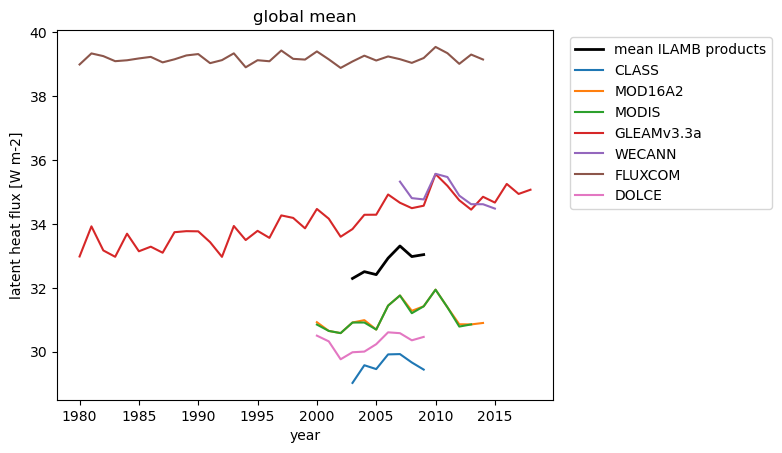

In [ ]:
ilamb_et_mmm.plot(lw=2, c="k", label="mean ILAMB products")
for model, da in ilamb_et_ts.items():
    da.plot(label=model)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.title("global mean")

Text(0.5, 1.0, 'global mean')

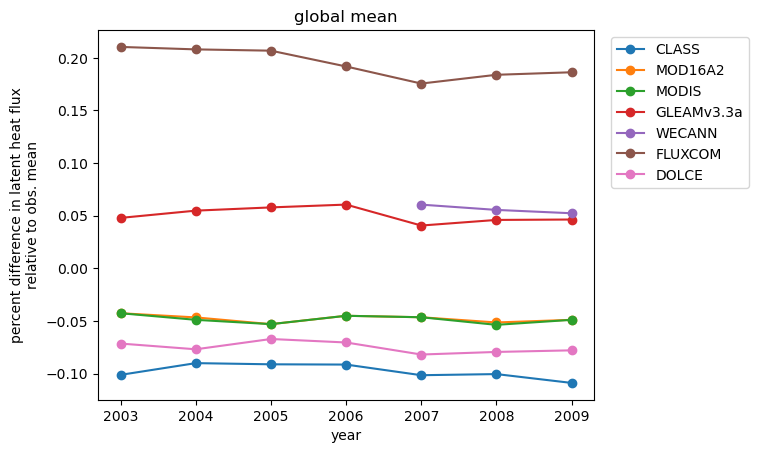

In [44]:
for model in ilamb_et_spread.model:
    ilamb_et_spread.sel(model=model).plot(marker="o", label=model.values)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel("percent difference in latent heat flux\nrelative to obs. mean")
plt.title("global mean")

# Plot histogram

(array([0., 0., 1., 0., 4., 1., 2., 1., 6., 3., 4., 3., 2., 0.]),
 array([32.  , 32.75, 33.5 , 34.25, 35.  , 35.75, 36.5 , 37.25, 38.  ,
        38.75, 39.5 , 40.25, 41.  , 41.75, 42.5 ]),
 [<matplotlib.patches.Polygon at 0x7f57802677d0>])

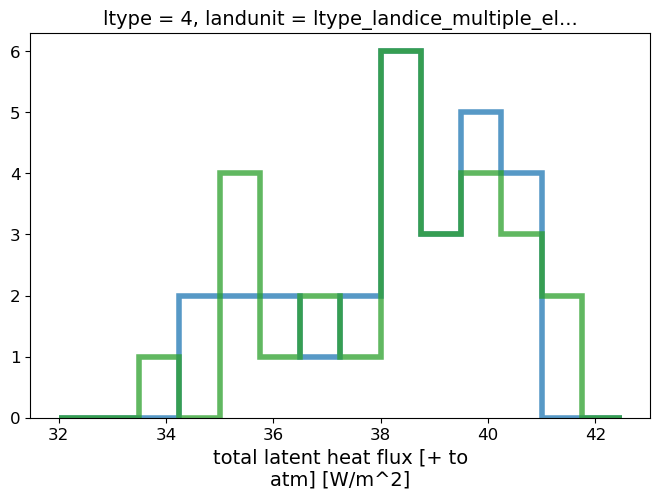

In [380]:
bin_width = 0.75
alpha = 0.75
density = False

bins = np.arange(32, 42 + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(8, 5))
fhist_et_tm.plot.hist(ax=ax, bins=bins, density=density, alpha=alpha, color="tab:blue", histtype='step', lw=4)
ohist_et_tm.plot.hist(ax=ax, bins=bins, density=density, alpha=alpha, color="tab:green", histtype='step', lw=4)
# lens_et_tm.plot.hist(ax=ax, bins=bins, density=density, alpha=alpha, color="tab:orange", histtype='step', lw=4)
# goga_et_tm.plot.hist(ax=ax, bins=bins, density=density, alpha=alpha, color="indianred", histtype='step', lw=4)

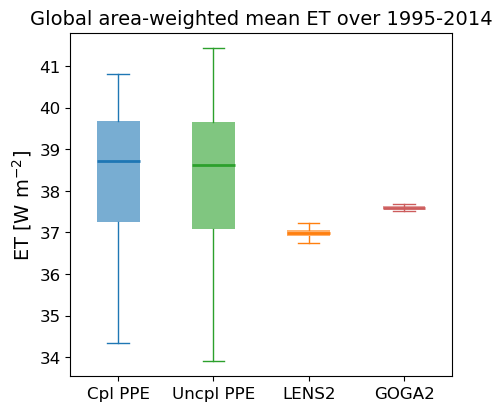

In [460]:
fig, ax = plt.subplots(figsize=(4.5, 4), layout='constrained')
colors = ['tab:blue', 'tab:green', 'tab:orange', 'indianred']
boxlines = ax.boxplot(
    [fhist_et_tm, ohist_et_tm, lens_et_tm, goga_et_tm],
    patch_artist=True,
    tick_labels=['Cpl PPE', 'Uncpl PPE', 'LENS2', 'GOGA2'],
)

for patch, color in zip(boxlines['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(0)

for median, color in zip(boxlines["medians"], colors):
    x = np.mean(median.get_xdata())
    y = np.mean(median.get_ydata())
    median.set_linestyle("-")
    median.set_color(color)
    median.set_linewidth(2)

for i, (whisker, cap) in enumerate(zip(boxlines["whiskers"], boxlines["caps"])):
    whisker.set_linestyle("-")
    whisker.set_color(colors[i//2])
    whisker.set_linewidth(1)

    cap.set_linestyle("-")
    cap.set_color(colors[i//2])
    cap.set_linewidth(1)

# ax.tick_params(axis="x", labelrotation=25)
ax.set_ylabel("ET [W m$^{-2}$]")
ax.set_title("Global area-weighted mean ET over 1995-2014")

fig.savefig("fig/for/abby/boxplot.all.global.1995-2014.png", dpi=300, bbox_inches='tight')

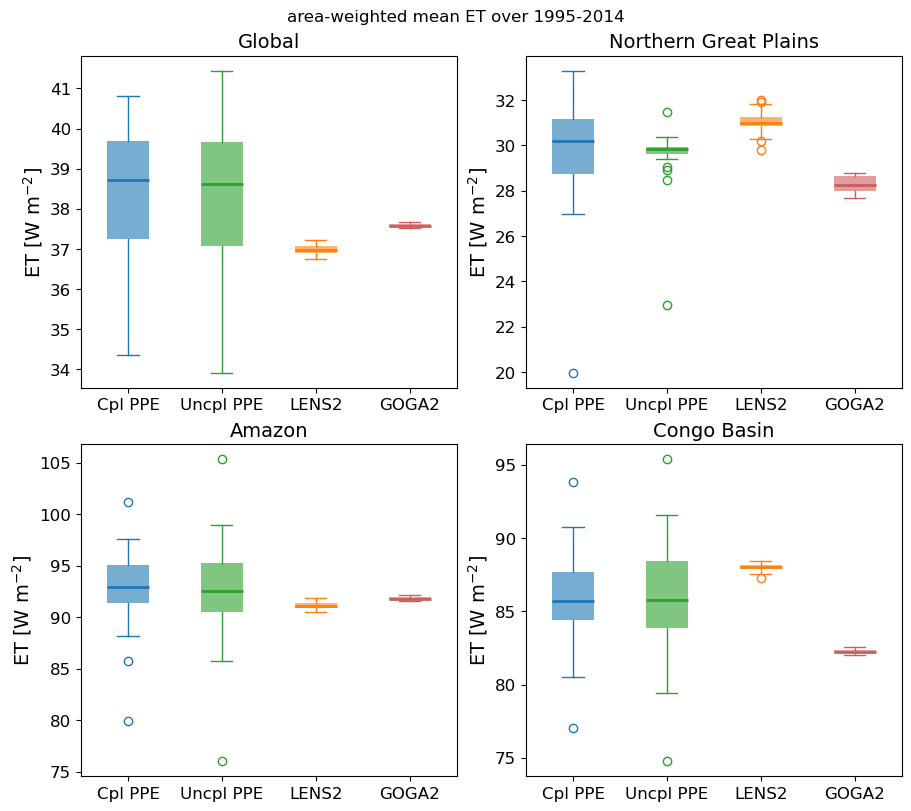

In [459]:
fig, axs = plt.subplots(2, 2, figsize=(9,8), layout='constrained')
ax = axs.ravel()

colors = ['tab:blue', 'tab:green', 'tab:orange', 'indianred']
reg_da_list = [
    [fhist_et_tm, ohist_et_tm, lens_et_tm, goga_et_tm],
    [fhist_et_tm_ngp, ohist_et_tm_ngp, lens_et_tm_ngp, goga_et_tm_ngp],
    [fhist_et_tm_amazon, ohist_et_tm_amazon, lens_et_tm_amazon, goga_et_tm_amazon],
    [fhist_et_tm_congo, ohist_et_tm_congo, lens_et_tm_congo, goga_et_tm_congo],
]
reg_label_list = ["Global", "Northern Great Plains", "Amazon", "Congo Basin"]

for i, (da_list, label) in enumerate(zip(reg_da_list, reg_label_list)):
    boxlines = ax[i].boxplot(
        da_list,
        patch_artist=True,
        tick_labels=['Cpl PPE', 'Uncpl PPE', 'LENS2', 'GOGA2']
    )

    for patch, color in zip(boxlines['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        patch.set_linewidth(0)

    for median, color in zip(boxlines["medians"], colors):
        median.set_linestyle("-")
        median.set_color(color)
        median.set_linewidth(2)

    for flier, color in zip(boxlines["fliers"], colors):
        flier.set_markeredgecolor(color)
        # flier.set_linewidth(2)

    for j, (whisker, cap) in enumerate(zip(boxlines["whiskers"], boxlines["caps"])):
        whisker.set_linestyle("-")
        whisker.set_color(colors[j//2])
        whisker.set_linewidth(1)

        cap.set_linestyle("-")
        cap.set_color(colors[j//2])
        cap.set_linewidth(1)

    ax[i].set_ylabel("ET [W m$^{-2}$]")
    ax[i].set_title(label, loc="center")

fig.suptitle("area-weighted mean ET over 1995-2014")

fig.savefig("fig/for/abby/boxplot.all.global_ngp_amazon_congo.1995-2014.png", dpi=300, bbox_inches='tight')

In [440]:
boxlines['fliers']

# Plot time series

In [16]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

## Modified for Abby

In [152]:
# FHIST_COLOR = xclim.plot.whiten("#882255", 0.6)
FHIST_COLOR = xclim.plot.whiten("#EE7733", 0.6)
# OHIST_COLOR = xclim.plot.whiten("#EE7733", 0.6)
OHIST_COLOR = xclim.plot.whiten("#117733", 0.6)
ILAMB_COLOR = xclim.plot.whiten("k", 0.2)

CONV_WM2_TO_MMYEAR = (86400 * 365) / 2.5e6

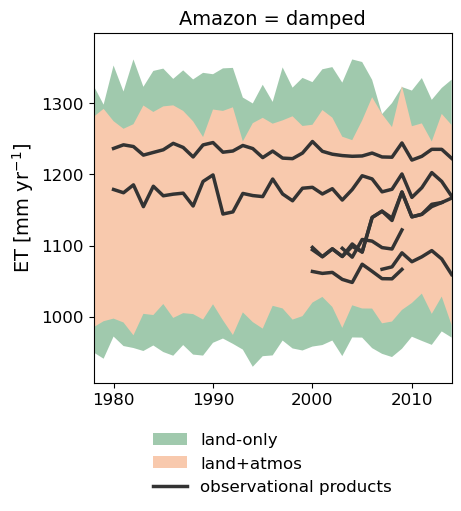

In [153]:
# colors = [FHIST_COLOR, OHIST_COLOR]
# tseries = [fhist_et_ts_ngp, ohist_et_ts_ngp]
# labels = ["land+atmos", "land-only"]

colors = [OHIST_COLOR, FHIST_COLOR]
tseries = [ohist_et_ts_amazon, fhist_et_ts_amazon]
labels = ["land-only", "land+atmos"]

title = "Amazon = damped"

fig, ax = plt.subplots(figsize=(4.5, 5), layout='constrained')

# Plots PPEs
for c, ts, lb in zip(colors, tseries, labels):
    ax.fill_between(
        ts.year,
        ts.min(dim='member') * CONV_WM2_TO_MMYEAR,
        ts.max(dim='member') * CONV_WM2_TO_MMYEAR,
        facecolor=c,
        label=lb,
    )


# Plot ILAMB datasets
for i, (model, da) in enumerate(ilamb_et_ts_amazon.items()):
    da_trunc = da.sel(year=slice(None, 2014)) * CONV_WM2_TO_MMYEAR
    label = "observational products" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c=ILAMB_COLOR, ls="-", lw=2.5, label=label, zorder=100)

ax.set_xlim(1978, 2014)

ax.set_title(title)
ax.set_ylabel("ET [mm yr$^{-1}$]")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=12, fancybox=False, frameon=False)

# fig.savefig("fig/for/abby/ens_filled_range.ilamb_fhist_offlhist.amazon.modified_for_abby.png", dpi=300, bbox_inches="tight")

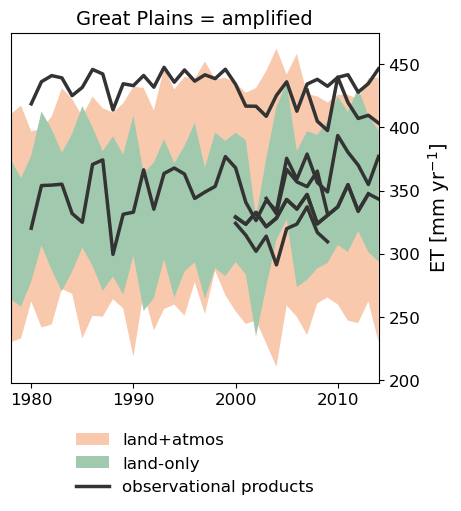

In [149]:
title = "Great Plains = amplified"

colors = [FHIST_COLOR, OHIST_COLOR]
tseries = [fhist_et_ts_ngp, ohist_et_ts_ngp]
labels = ["land+atmos", "land-only"]

fig, ax = plt.subplots(figsize=(4.5, 5), layout='constrained')

# Plots PPEs
for c, ts, lb in zip(colors, tseries, labels):
    ax.fill_between(
        ts.year,
        ts.min(dim='member') * CONV_WM2_TO_MMYEAR,
        ts.max(dim='member') * CONV_WM2_TO_MMYEAR,
        facecolor=c,
        label=lb,
    )


# Plot ILAMB datasets
for i, (model, da) in enumerate(ilamb_et_ts_ngp.items()):
    da_trunc = da.sel(year=slice(None, 2014)) * CONV_WM2_TO_MMYEAR
    label = "observational products" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c=ILAMB_COLOR, ls="-", lw=2.5, label=label, zorder=100)

ax.set_xlim(1978, 2014)
# ax.set_ylim(15, 38)

ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

ax.set_title(title)
ax.set_ylabel("ET [mm yr$^{-1}$]")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=12, fancybox=False, frameon=False)

# fig.savefig("fig/for/abby/ens_filled_range.ilamb_fhist_offlhist.ngp.modified_for_abby.png", dpi=300, bbox_inches="tight")

## Rest

In [ ]:
def plot_ensemble_ranges(da_list, da_label, da_color, alpha=0.25, ax=None, **kwargs):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5), layout='constrained', **kwargs)
        for da, label, color in zip(da_list, da_label, da_color):
            ax.fill_between(
                da.year,
                da.min(dim='member'),
                da.max(dim='member'),
                alpha=alpha,
                facecolor=color,
                label=label,
            )
        return fig, ax
    
    for da, label, color in zip(da_list, da_label, da_color):
        ax.fill_between(
            da.year,
            da.min(dim='member'),
            da.max(dim='member'),
            alpha=alpha,
            facecolor=color,
            label=label,
        )

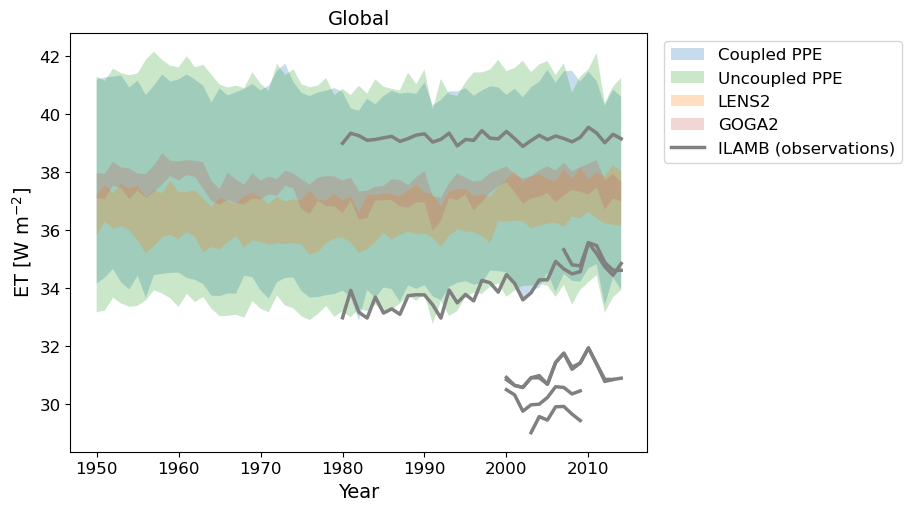

In [461]:
fig, ax = plot_ensemble_ranges(
    [fhist_et_ts, ohist_et_ts, lens_et_ts, goga_et_ts],
    ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
    ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
    dpi=100,
)

# Plot ILAMB datasets
start_yr = 1950
stop_yr = 2014
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (model, da) in enumerate(ilamb_et_ts.items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))
    label = "ILAMB (observations)" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=label, zorder=100)

ax.set_title("Global")
ax.set_xlabel("Year")
ax.set_ylabel("ET [W m$^{-2}$]")
ax.legend(bbox_to_anchor=(1.015, 1), fontsize=12)

fig.savefig("fig/for/abby/ens_filled_range.all.global.png", dpi=300, bbox_inches="tight")

In [297]:
# fig, ax = plot_ensemble_ranges(
#     [fhist_et_ts, ohist_et_ts, lens_et_ts, goga_et_ts],
#     ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
#     ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
#     dpi=100,
# )

# fig, ax = plot_ensemble_ranges(
#     [fhist_et_ts, lens_et_ts, goga_et_ts],
#     ["Coupled PPE", "LENS2", "GOGA2"],
#     ['tab:blue', 'tab:orange', 'indianred'],
#     dpi=100,
# )

# # fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
# ax.set_xlim(np.float64(1946.8), np.float64(2017.2))
# ax.set_ylim(np.float64(28.36913687998099), np.float64(42.80551782912014))

# # Plot ILAMB datasets
# start_yr = 1950
# stop_yr = 2014
# cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
# for i, (model, da) in enumerate(ilamb_et_ts.items()):
#     da_trunc = da.sel(year=slice(start_yr, stop_yr))
#     label = "ILAMB (observations)" if i == 0 else None
#     ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=label, zorder=100)

# ax.set_title("Global")
# ax.set_xlabel("Year")
# ax.set_ylabel("ET [W m$^{-2}$]")
# ax.legend(loc='upper left', bbox_to_anchor=(1.015, 1), fontsize=12)

# fig.savefig("fig/for/abby/ens_filled_range.ilamb_lens_goga_fhist.global.png", dpi=300, bbox_inches="tight")

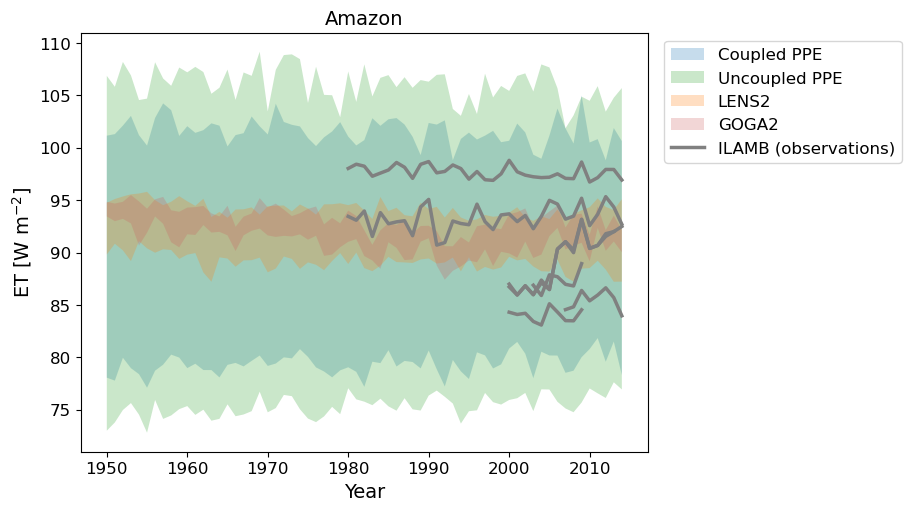

In [462]:
fig, ax = plot_ensemble_ranges(
    [fhist_et_ts_amazon, ohist_et_ts_amazon, lens_et_ts_amazon, goga_et_ts_amazon],
    ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
    ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
    dpi=100,
)

# Plot ILAMB datasets
start_yr = 1950
stop_yr = 2014
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (model, da) in enumerate(ilamb_et_ts_amazon.items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))
    label = "ILAMB (observations)" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=label, zorder=100)

ax.set_title("Amazon")
ax.set_xlabel("Year")
ax.set_ylabel("ET [W m$^{-2}$]")
ax.legend(bbox_to_anchor=(1.015, 1), fontsize=12)

fig.savefig("fig/for/abby/ens_filled_range.all.amazon.png", dpi=300, bbox_inches="tight")

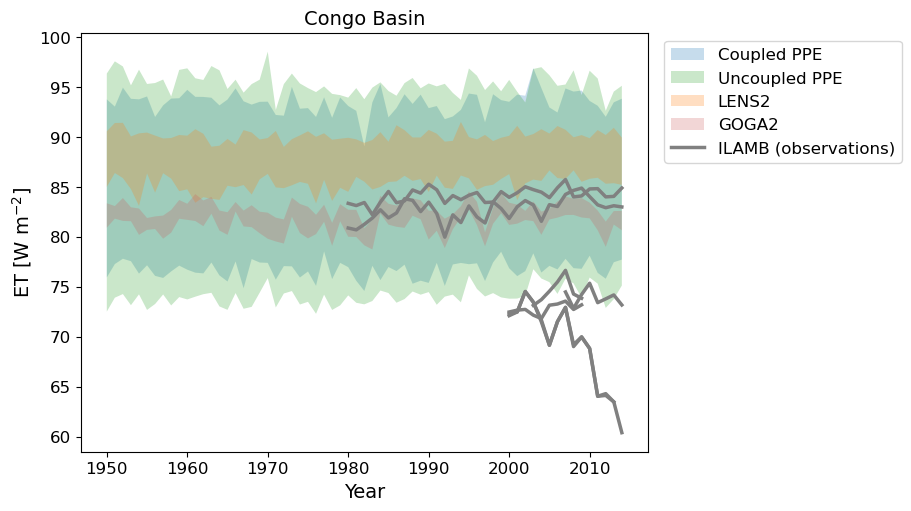

In [463]:
fig, ax = plot_ensemble_ranges(
    [fhist_et_ts_congo, ohist_et_ts_congo, lens_et_ts_congo, goga_et_ts_congo],
    ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
    ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
    dpi=100,
)

# Plot ILAMB datasets
start_yr = 1950
stop_yr = 2014
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (model, da) in enumerate(ilamb_et_ts_congo.items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))
    label = "ILAMB (observations)" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=label, zorder=100)

ax.set_title("Congo Basin")
ax.set_xlabel("Year")
ax.set_ylabel("ET [W m$^{-2}$]")
ax.legend(bbox_to_anchor=(1.015, 1), fontsize=12)

fig.savefig("fig/for/abby/ens_filled_range.all.congo.png", dpi=300, bbox_inches="tight")

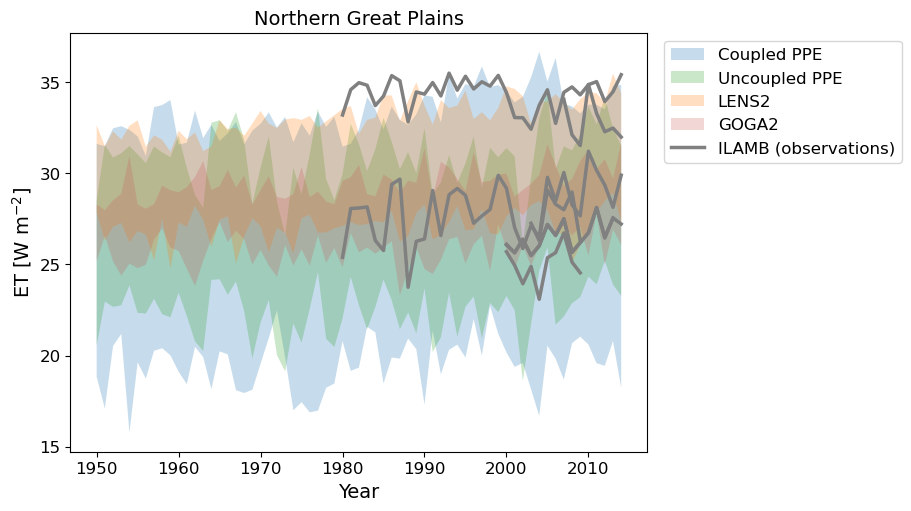

In [464]:
fig, ax = plot_ensemble_ranges(
    [fhist_et_ts_ngp, ohist_et_ts_ngp, lens_et_ts_ngp, goga_et_ts_ngp],
    ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
    ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
    dpi=100,
)

# Plot ILAMB datasets
start_yr = 1950
stop_yr = 2014
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (model, da) in enumerate(ilamb_et_ts_ngp.items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))
    label = "ILAMB (observations)" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=label, zorder=100)

ax.set_title("Northern Great Plains")
ax.set_xlabel("Year")
ax.set_ylabel("ET [W m$^{-2}$]")
ax.legend(bbox_to_anchor=(1.015, 1), fontsize=12)

fig.savefig("fig/for/abby/ens_filled_range.all.ngp.png", dpi=300, bbox_inches="tight")

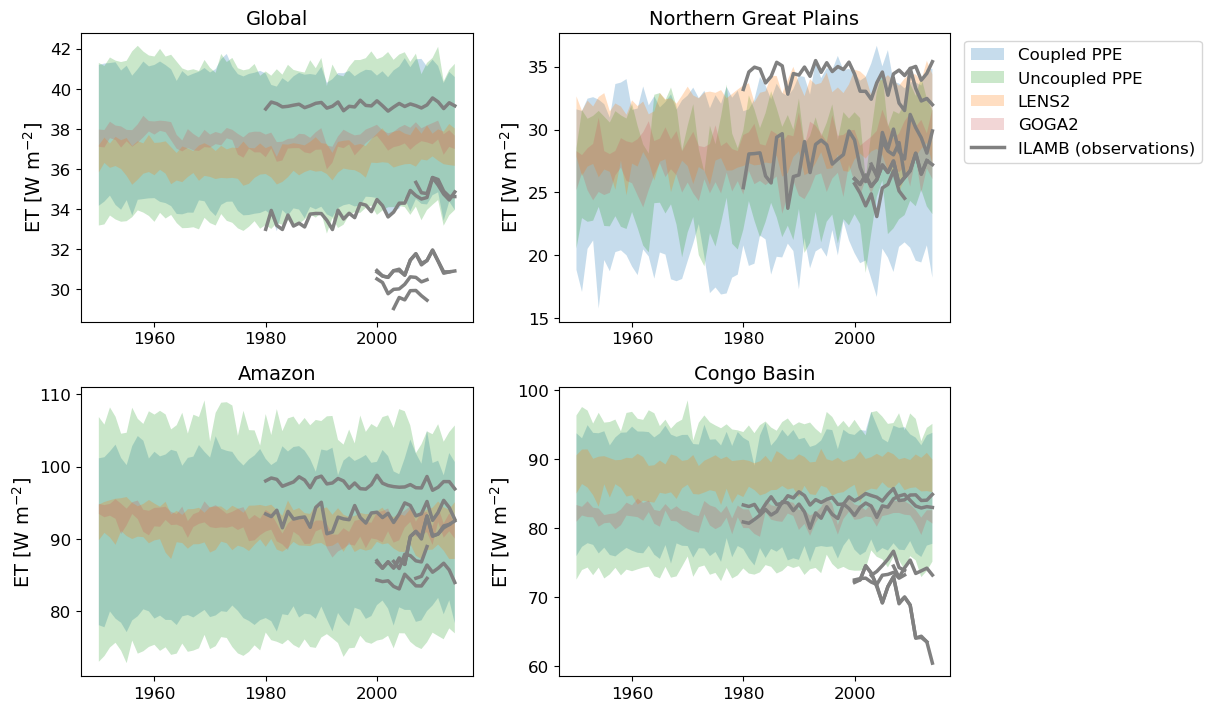

In [465]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), layout='constrained', gridspec_kw={'hspace': 0.05, 'wspace': 0.025}, dpi=100)
ax = axs.ravel()

reg_da_list = [
    [fhist_et_ts, ohist_et_ts, lens_et_ts, goga_et_ts],
    [fhist_et_ts_ngp, ohist_et_ts_ngp, lens_et_ts_ngp, goga_et_ts_ngp],
    [fhist_et_ts_amazon, ohist_et_ts_amazon, lens_et_ts_amazon, goga_et_ts_amazon],
    [fhist_et_ts_congo, ohist_et_ts_congo, lens_et_ts_congo, goga_et_ts_congo],
]
reg_ilamb_list = [
    ilamb_et_ts,
    ilamb_et_ts_ngp,
    ilamb_et_ts_amazon,
    ilamb_et_ts_congo,
]
reg_label_list = ["Global", "Northern Great Plains", "Amazon", "Congo Basin"]

for i, (da_list, ilamb_dict, label) in enumerate(zip(reg_da_list, reg_ilamb_list, reg_label_list)):
    # Plot model output
    plot_ensemble_ranges(
        da_list,
        ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
        ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
        ax=ax[i],
    )

    # Plot ILAMB datasets
    start_yr = 1950
    stop_yr = 2014
    cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
    for j, (model, da) in enumerate(ilamb_dict.items()):
        da_trunc = da.sel(year=slice(start_yr, stop_yr))
        ilamb_label = "ILAMB (observations)" if j == 0 else None
        ax[i].plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=ilamb_label, zorder=100)
    
    ax[i].set_ylabel("ET [W m$^{-2}$]")
    ax[i].set_title(label)

ax[1].legend(bbox_to_anchor=(1.015, 1), fontsize=12)

fig.savefig("fig/for/abby/ens_filled_range.all.global_ngp_amazon_congo.png", dpi=300, bbox_inches="tight")

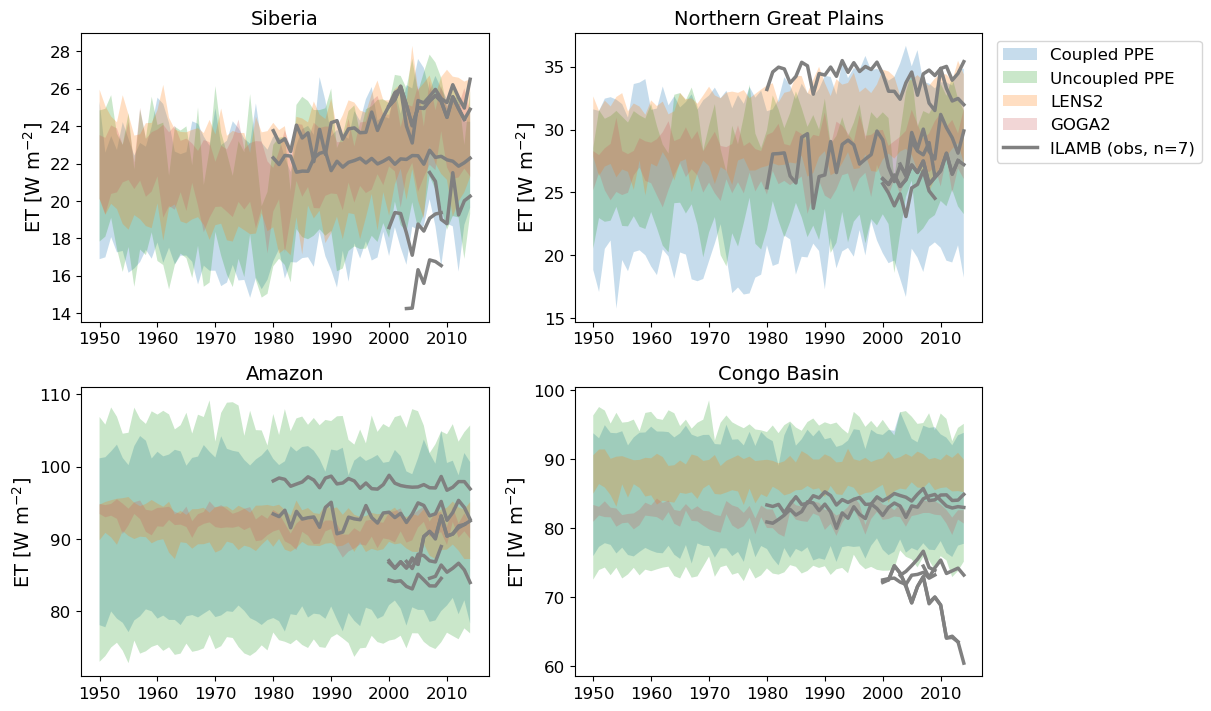

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), layout='constrained', gridspec_kw={'hspace': 0.05, 'wspace': 0.025}, dpi=100)
ax = axs.ravel()

reg_da_list = [
    [fhist_et_ts_nru, ohist_et_ts_nru, lens_et_ts_nru, goga_et_ts_nru],
    [fhist_et_ts_ngp, ohist_et_ts_ngp, lens_et_ts_ngp, goga_et_ts_ngp],
    [fhist_et_ts_amazon, ohist_et_ts_amazon, lens_et_ts_amazon, goga_et_ts_amazon],
    [fhist_et_ts_congo, ohist_et_ts_congo, lens_et_ts_congo, goga_et_ts_congo],
]
reg_ilamb_list = [
    ilamb_et_ts_nru,
    ilamb_et_ts_ngp,
    ilamb_et_ts_amazon,
    ilamb_et_ts_congo,
]
reg_label_list = ["nrueria", "Northern Great Plains", "Amazon", "Congo Basin"]

for i, (da_list, ilamb_dict, label) in enumerate(zip(reg_da_list, reg_ilamb_list, reg_label_list)):
    # Plot model output
    plot_ensemble_ranges(
        da_list,
        ["Coupled PPE", "Uncoupled PPE", "LENS2", "GOGA2"],
        ['tab:blue', 'tab:green', 'tab:orange', 'indianred'],
        ax=ax[i],
    )

    # Plot ILAMB datasets
    start_yr = 1950
    stop_yr = 2014
    cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
    for j, (model, da) in enumerate(ilamb_dict.items()):
        da_trunc = da.sel(year=slice(start_yr, stop_yr))
        ilamb_label = f"ILAMB (obs, n={len(ilamb_dict.keys())})" if j == 0 else None
        ax[i].plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=ilamb_label, zorder=100)
    
    ax[i].set_ylabel("ET [W m$^{-2}$]")
    ax[i].set_title(label)

ax[1].legend(bbox_to_anchor=(1.015, 1), fontsize=12)

fig.savefig("fig/for/abby/ens_filled_range.all.nrueria_ngp_amazon_congo.png", dpi=300, bbox_inches="tight")

In [ ]:
mask = xr.zeros_like(grid_lens.LANDAREA, dtype=np.int16)
mask = xr.where(grid_lens.LANDAREA > 0, mask, 0)
mask = xr.where(mask_nru_lens & (grid_lens.LANDAREA > 0), 1, mask)
mask = xr.where(mask_ngp_lens & (grid_lens.LANDAREA > 0), 2, mask)
mask = xr.where(mask_amazon_lens & (grid_lens.LANDAREA > 0), 3, mask)
mask = xr.where(mask_congo_lens & (grid_lens.LANDAREA > 0), 4, mask)

mask.attrs["region_names"] = {
    0: "",
    1: "nrueria",
    2: "Northern Great Plains",
    3: "Amazon",
    4: "Congo Basin",
}

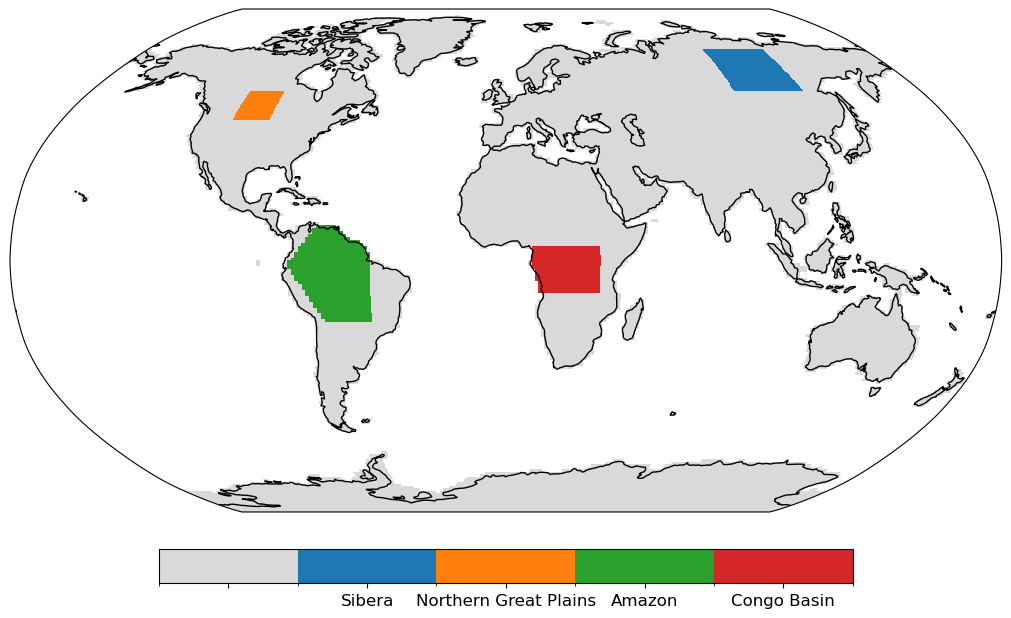

In [ ]:
# Discrete colormap with one color per region
region_names = [
    "",
    "nruera",
    "Northern Great Plains",
    "Amazon",
    "Congo Basin",
]
region_colors = [
    "#d9d9d9", 
    "tab:blue", 
    "tab:orange", 
    "tab:green",
    "tab:red",
]
cmap = mcolors.ListedColormap(region_colors)
norm = mcolors.BoundaryNorm(np.arange(-0.5, len(region_colors) + 0.5, 1), cmap.N)

fig = plt.figure(figsize=(10, 8), dpi=100, layout='constrained')
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

p = mask.where(grid_lens.LANDAREA > 0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
)

ax.coastlines()

cbar = fig.colorbar(
    p,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    fraction=0.05,
    ticks=np.arange(len(region_colors)),
)
cbar.set_ticklabels(region_names)

ax.set_title("")

fig.savefig("fig/for/abby/region_map.png", dpi=300, bbox_inches="tight")

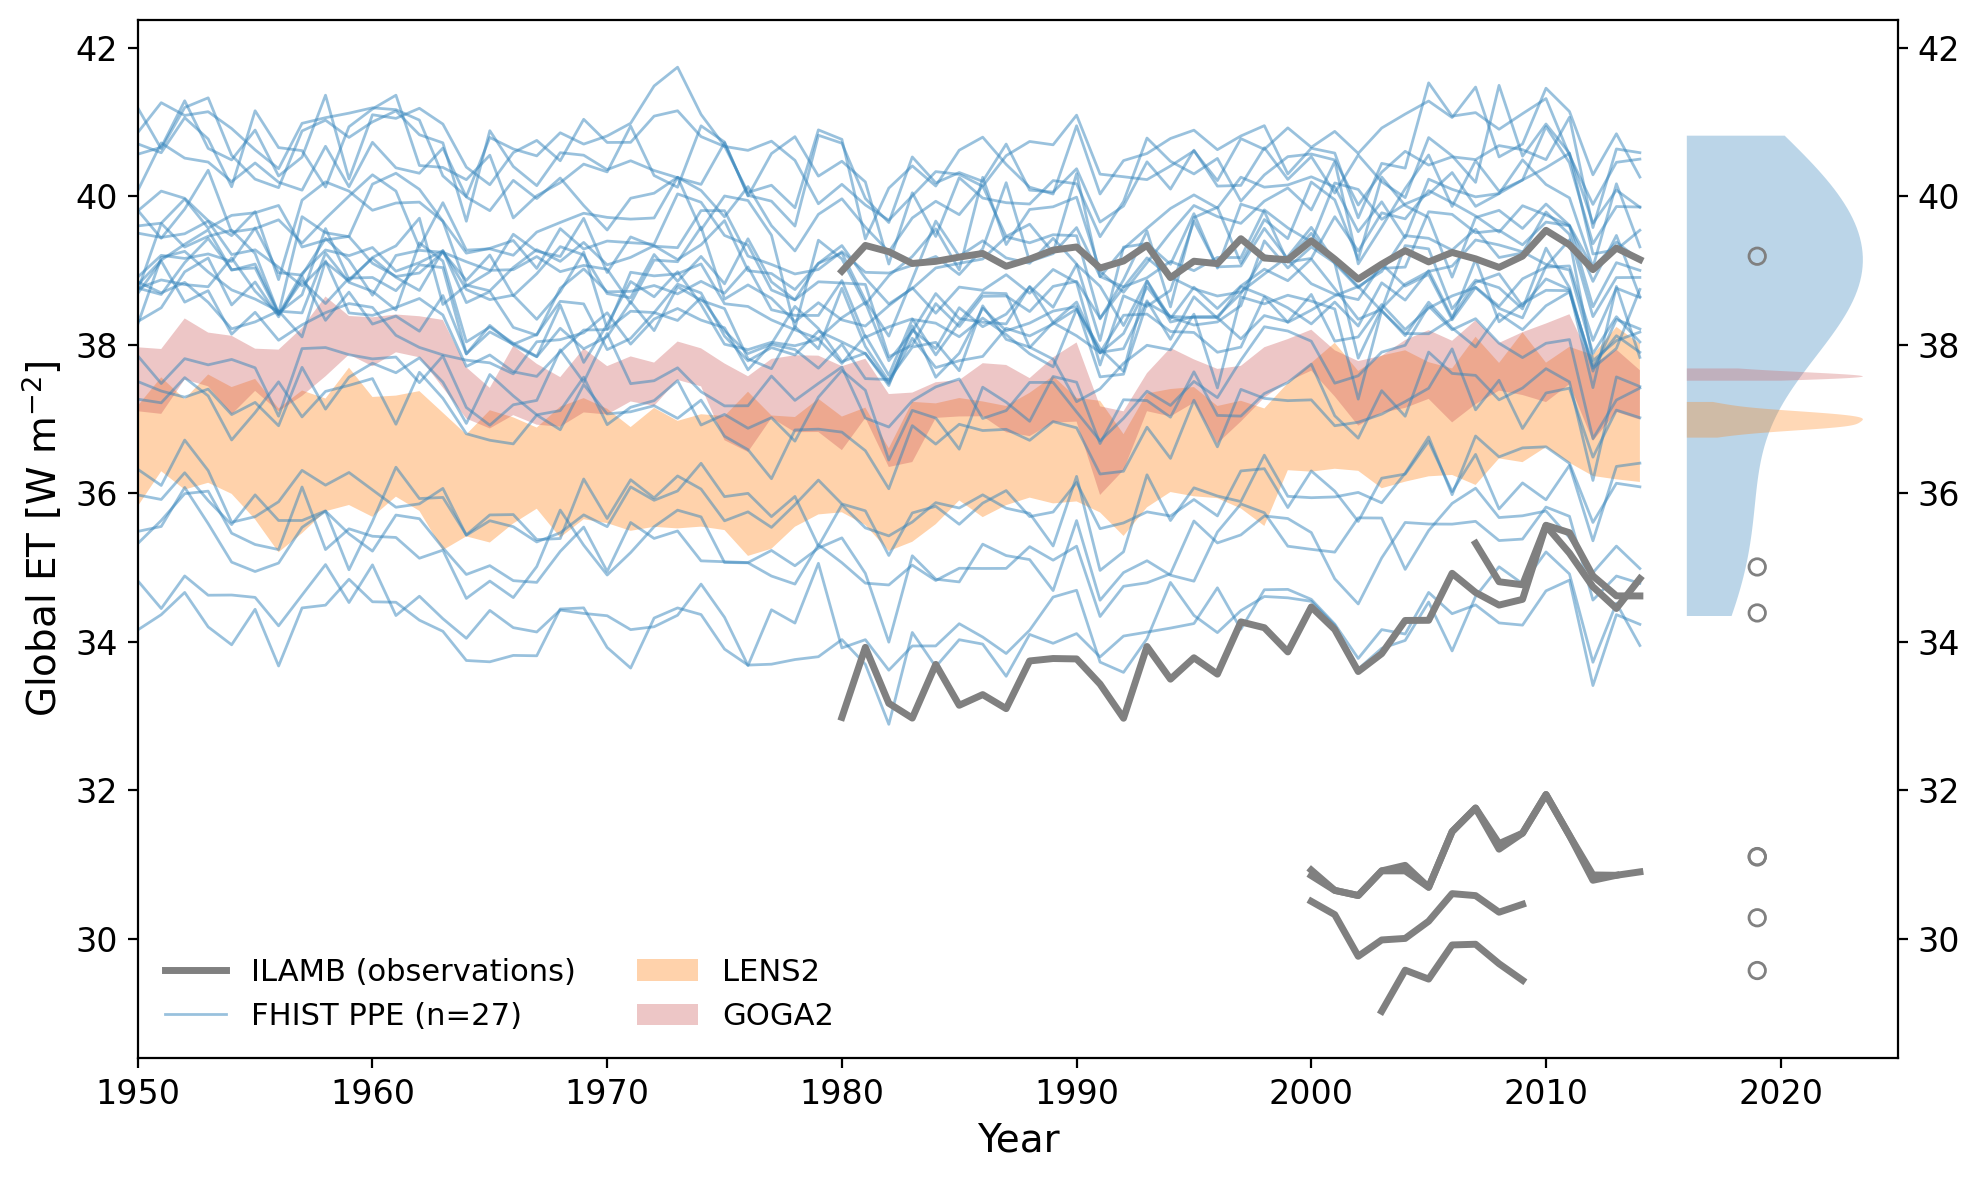

In [470]:
name = "Global ET"
units = "W m$^{-2}$"
start_yr = 1950
stop_yr = 2014

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=200)


# Plot ILAMB datasets
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (model, da) in enumerate(ilamb_et_ts.items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))

    # ax.plot(da_trunc.year, da_trunc, c=cs_ilamb[i], ls="-", lw=2.5, label=model, zorder=100)
    # ax.scatter(stop_yr + 5, ilamb_et_tm[model], marker="o", s=35, edgecolor=cs_ilamb[i], facecolor="none", zorder=100)

    ilamb_label = "ILAMB (observations)" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=ilamb_label, zorder=100)
    ax.scatter(stop_yr + 5, ilamb_et_tm[model], marker="o", s=35, edgecolor="gray", facecolor="none", zorder=100)



# Plot FHIST PPE
das = [fhist_et_ts]
das_violin = [fhist_et_tm]
das_labels = ["FHIST PPE"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:blue"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


# # Plot OFFLHIST PPE
# das = [ohist_et_ts]
# das_violin = [ohist_et_tm]
# das_labels = ["OFFLHIST PPE"]
# _, ax = xclim.plot.plot_ensemble_line(
#     das=das,
#     das_violin=das_violin,
#     das_labels=das_labels,
#     ylabel=f"{name} [{units}]",
#     plot_dim="year",
#     xlabel="Year",
#     highlight_member=[None],
#     colors=["tab:green"],
#     violin_xrange=None,
#     violin_settings={"x": stop_yr + 2},
#     add_legend=False,
#     ax=ax,
# )


# # Plot LENS2
# lens_et_ts.mean(dim='member').plot(ax=ax, color='tab:orange', alpha=1, lw=2, _labels=False)

# das = [lens_et_ts]
# das_violin = [lens_et_tm]
# das_labels = ["LENS2"]
# _, ax = xclim.plot.plot_ensemble_line(
#     das=das,
#     das_violin=das_violin,
#     das_labels=das_labels,
#     ylabel=f"{name} [{units}]",
#     plot_dim="year",
#     xlabel="Year",
#     highlight_member=[None],
#     colors=["tab:orange"],
#     violin_xrange=None,
#     violin_settings={"x": stop_yr + 2},
#     add_legend=False,
#     ax=ax,
# )


# # Plot GOGA2
# goga_et_ts.mean(dim='member').plot(ax=ax, color='indianred', alpha=1, lw=2, _labels=False)

# das = [goga_et_ts]
# das_violin = [goga_et_tm]
# das_labels = ["GOGA2"]
# _, ax = xclim.plot.plot_ensemble_line(
#     das=das,
#     das_violin=das_violin,
#     das_labels=das_labels,
#     ylabel=f"{name} [{units}]",
#     plot_dim="year",
#     xlabel="Year",
#     highlight_member=[None],
#     colors=["indianred"],
#     violin_xrange=None,
#     violin_settings={"x": stop_yr + 2},
#     add_legend=False,
#     ax=ax,
# )

das_violin = [lens_et_tm]
das_labels = ["LENS2"]
_, ax = xclim.plot.plot_ensemble_violin(
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:orange"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)

das_violin = [goga_et_tm]
das_labels = ["GOGA2"]
_, ax = xclim.plot.plot_ensemble_violin(
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    xlabel="Year",
    highlight_member=[None],
    colors=["indianred"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)

plot_ensemble_ranges(
    [lens_et_ts, goga_et_ts],
    ["LENS2", "GOGA2"],
    ['tab:orange', 'indianred'],
    ax=ax,
    alpha=0.35
)

ax.set_xlim(1950, 2025)
ax.legend(loc="lower left", ncols=2, fontsize=11, fancybox=False, frameon=False)

fig.savefig("fig/for/abby/time_series_violin.ilamb_lens_goga_fhist.png", dpi=300, bbox_inches="tight")

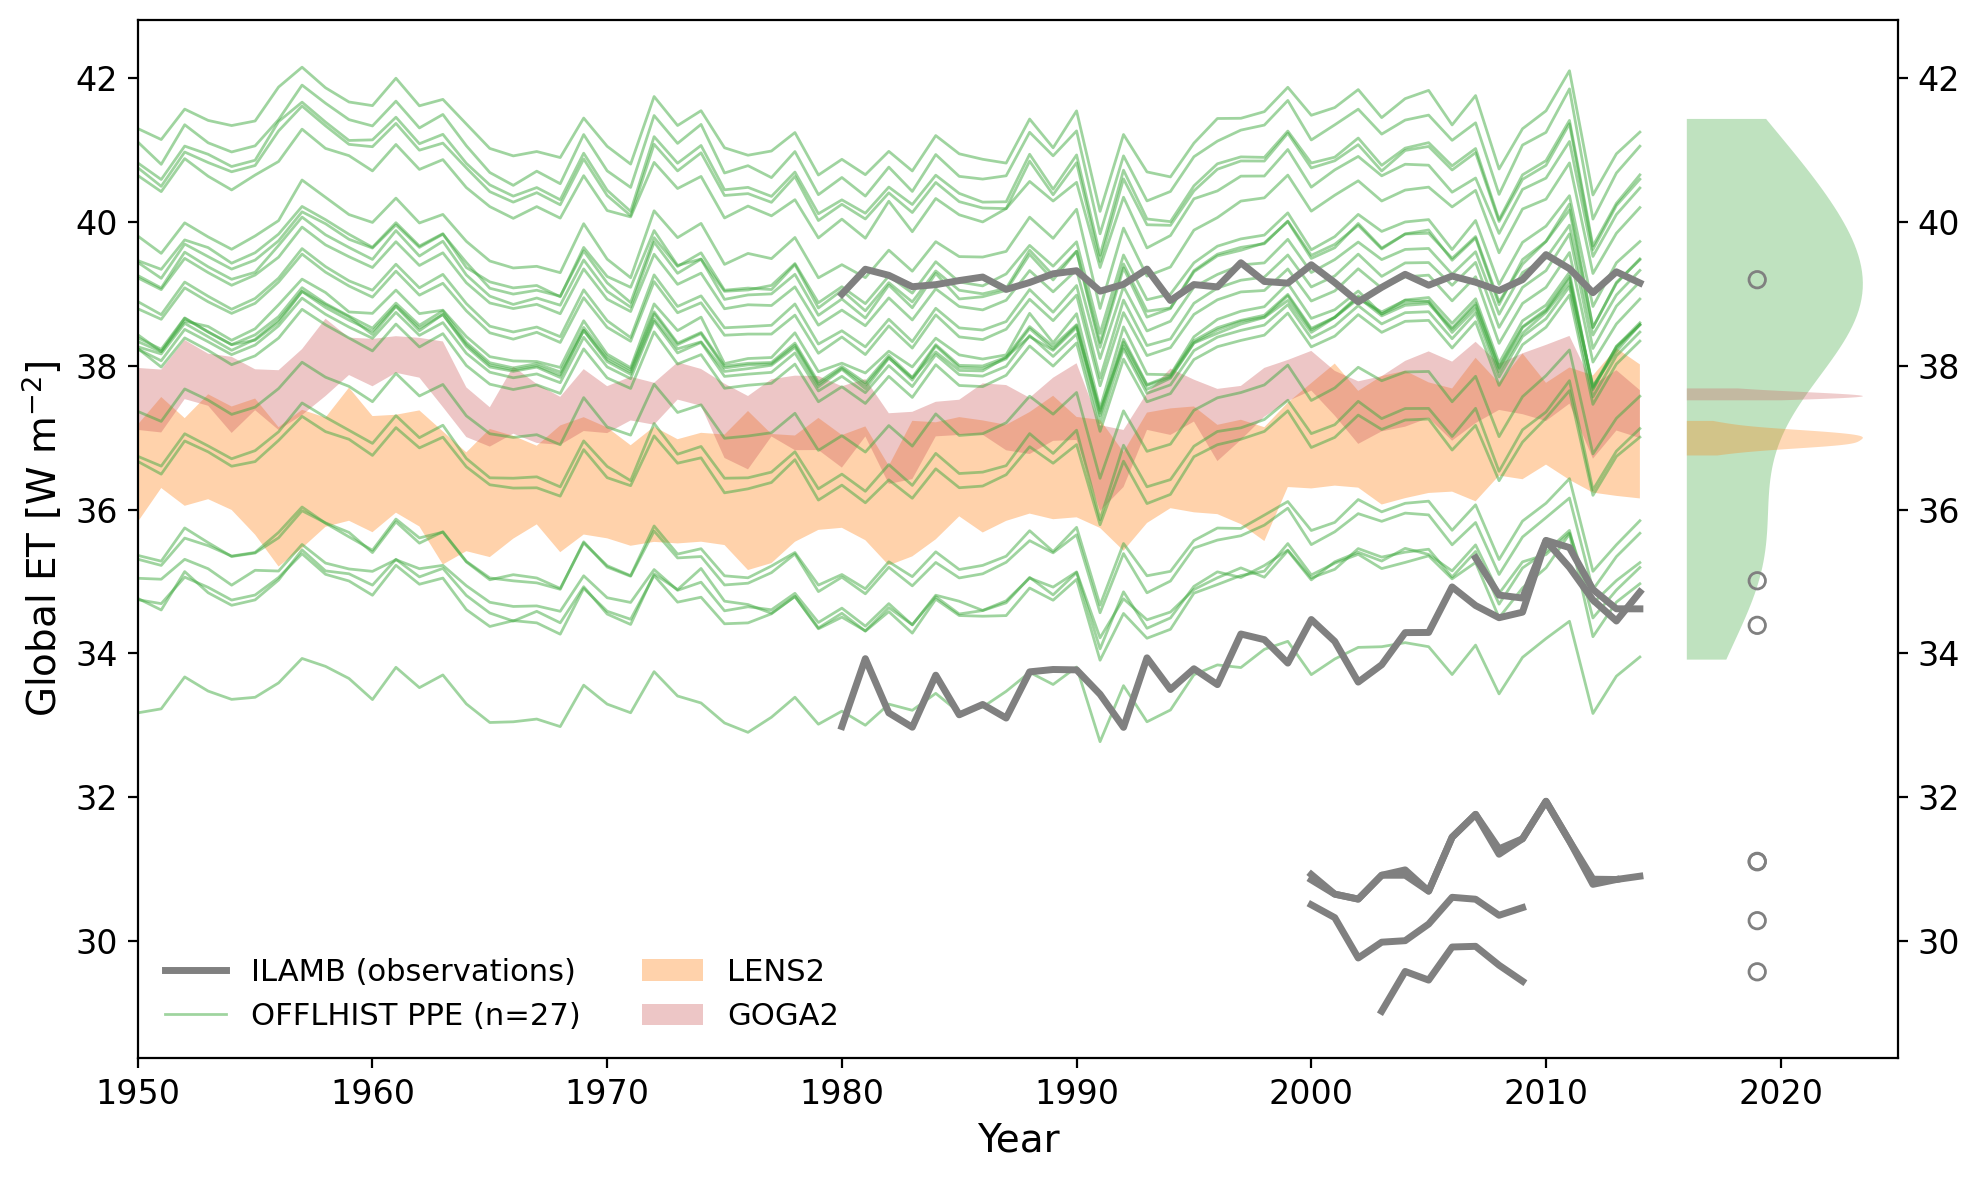

In [471]:
name = "Global ET"
units = "W m$^{-2}$"
start_yr = 1950
stop_yr = 2014

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=200)


# Plot ILAMB datasets
cs_ilamb = list(mcolors.TABLEAU_COLORS.keys())[2:]
for i, (model, da) in enumerate(ilamb_et_ts.items()):
    da_trunc = da.sel(year=slice(start_yr, stop_yr))

    # ax.plot(da_trunc.year, da_trunc, c=cs_ilamb[i], ls="-", lw=2.5, label=model, zorder=100)
    # ax.scatter(stop_yr + 5, ilamb_et_tm[model], marker="o", s=35, edgecolor=cs_ilamb[i], facecolor="none", zorder=100)

    ilamb_label = "ILAMB (observations)" if i == 0 else None
    ax.plot(da_trunc.year, da_trunc, c="gray", ls="-", lw=2.5, label=ilamb_label, zorder=100)
    ax.scatter(stop_yr + 5, ilamb_et_tm[model], marker="o", s=35, edgecolor="gray", facecolor="none", zorder=100)



# # Plot FHIST PPE
# das = [fhist_et_ts]
# das_violin = [fhist_et_tm]
# das_labels = ["FHIST PPE"]
# _, ax = xclim.plot.plot_ensemble_line(
#     das=das,
#     das_violin=das_violin,
#     das_labels=das_labels,
#     ylabel=f"{name} [{units}]",
#     plot_dim="year",
#     xlabel="Year",
#     highlight_member=[None],
#     colors=["tab:blue"],
#     violin_xrange=None,
#     violin_settings={"x": stop_yr + 2},
#     add_legend=False,
#     ax=ax,
# )


# Plot OFFLHIST PPE
das = [ohist_et_ts]
das_violin = [ohist_et_tm]
das_labels = ["OFFLHIST PPE"]
_, ax = xclim.plot.plot_ensemble_line(
    das=das,
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    plot_dim="year",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:green"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)


# # Plot LENS2
# lens_et_ts.mean(dim='member').plot(ax=ax, color='tab:orange', alpha=1, lw=2, _labels=False)

# das = [lens_et_ts]
# das_violin = [lens_et_tm]
# das_labels = ["LENS2"]
# _, ax = xclim.plot.plot_ensemble_line(
#     das=das,
#     das_violin=das_violin,
#     das_labels=das_labels,
#     ylabel=f"{name} [{units}]",
#     plot_dim="year",
#     xlabel="Year",
#     highlight_member=[None],
#     colors=["tab:orange"],
#     violin_xrange=None,
#     violin_settings={"x": stop_yr + 2},
#     add_legend=False,
#     ax=ax,
# )


# # Plot GOGA2
# goga_et_ts.mean(dim='member').plot(ax=ax, color='indianred', alpha=1, lw=2, _labels=False)

# das = [goga_et_ts]
# das_violin = [goga_et_tm]
# das_labels = ["GOGA2"]
# _, ax = xclim.plot.plot_ensemble_line(
#     das=das,
#     das_violin=das_violin,
#     das_labels=das_labels,
#     ylabel=f"{name} [{units}]",
#     plot_dim="year",
#     xlabel="Year",
#     highlight_member=[None],
#     colors=["indianred"],
#     violin_xrange=None,
#     violin_settings={"x": stop_yr + 2},
#     add_legend=False,
#     ax=ax,
# )

das_violin = [lens_et_tm]
das_labels = ["LENS2"]
_, ax = xclim.plot.plot_ensemble_violin(
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    xlabel="Year",
    highlight_member=[None],
    colors=["tab:orange"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)

das_violin = [goga_et_tm]
das_labels = ["GOGA2"]
_, ax = xclim.plot.plot_ensemble_violin(
    das_violin=das_violin,
    das_labels=das_labels,
    ylabel=f"{name} [{units}]",
    xlabel="Year",
    highlight_member=[None],
    colors=["indianred"],
    violin_xrange=None,
    violin_settings={"x": stop_yr + 2},
    add_legend=False,
    ax=ax,
)

plot_ensemble_ranges(
    [lens_et_ts, goga_et_ts],
    ["LENS2", "GOGA2"],
    ['tab:orange', 'indianred'],
    ax=ax,
    alpha=0.35
)

ax.set_xlim(1950, 2025)
ax.legend(loc="lower left", ncols=2, fontsize=11, fancybox=False, frameon=False)

fig.savefig("fig/for/abby/time_series_violin.ilamb_lens_goga_offlhist.png", dpi=300, bbox_inches="tight")